# Multi-scale

Can we link from our particle scale to the continuum?

In [7]:
import yaml

import matplotlib.pyplot as plt

import layer_models

In [2]:
# This is extracted from the code we used to manage the big parameter sweep,
# so the input is a bit eccentric and split into things we (used to) sweep over
# and things we kept fixed for a whole sweep...

# Our 'sweep' parameters (highlighted point in Fig ):
case_name = 'test'
delta_t_icb = -10.0
delta_x_icb = 0.008125
this_i0 = None # Take it from the yaml

# Other model parameters as yaml:
input_data = """
f_layer_thickness : 200000
xfe_outer_core : 0.83
growth_prefactor : 150.0
i0 : 1.000000E-11
surf_energy : 1.08
wetting_angle : 5.0
number_of_analysis_points : 100
number_of_knots : 5
r_icb : 1221500
r_cmb : 3480000
gruneisen_parameter : 1.5
chemical_diffusivity : 1.000000E-09
kinematic_viscosity : 2.000000E-06
thermal_conductivity : 100.0
max_time : 1.0E20
hetrogeneous_radius : 10.0e-10
"""

input_params = yaml.load(input_data, yaml.CLoader)

In [3]:
# Note that if BV freq is imaginary, or the case fails to run, output_data will be None...
cases_dict, output_data = layer_models.run_case(case_name, delta_t_icb, delta_x_icb, this_i0, input_params)

Dt = -10.0, delta_x = 0.008125, BV freq = 0.00022213856443482763, dT_liq = 75.86190718940907, dT_cond = 58.15753496004072


/Users/andreww/Code/slurry/flayer.py:508: RuntimeWarning: invalid value encountered in divide
  mean_particle_velocities[i] = np.mean((partial_densities * partial_velocities) /


Heat from crystalisation = 6.283611874717909 TW
Oxygen production rate = 2.7409723667471587e-08 Tg/s
Oxygen enrichment rate of outer core = 4.694942116025412e-05 wt. % Oxygen / Ga
maximum particle radius = 0.033483329504512764 m
maximum solid fraction = 1.368185474684128e-10
max_nucleation_rate = 8.931855885205271e-12


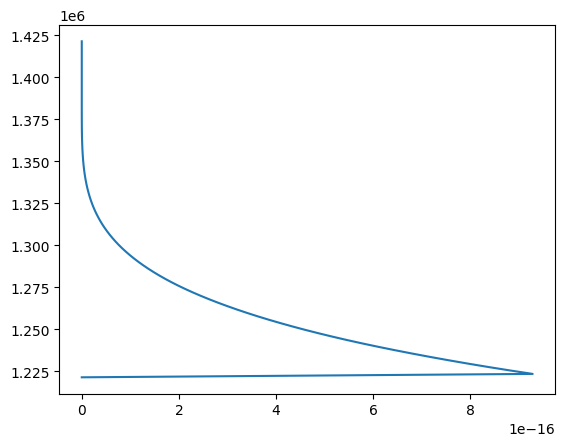

In [11]:
fig, ax = plt.subplots()

ax.plot(output_data["profiles"].mass_fraction_solid_production_rate, output_data["profiles"].radius)
plt.show()